## 1. Load Corpora
Download and load the Wikipedia and Stack Exchange politeness corpora from ConvoKit.

In [ ]:
from convokit import Corpus, download
# https://convokit.cornell.edu/documentation/stack_politeness.html for mor details
corpus_wiki = Corpus(filename=download("wikipedia-politeness-corpus"))
corpus_stack = Corpus(filename=download("stack-exchange-politeness-corpus"))
corpus_awry = Corpus(filename=download("conversations-gone-awry-corpus"))
corpus_reddit = Corpus(filename=download("reddit-corpus-small"))
corpus_ubuntu = Corpus(filename=download("ubuntu-chat-logs"))
corpus_emotional = Corpus(filename=download("emotional-support"))
modifier_list = ["a bit", "a little", "somewhat","slightly","kinda","sorta","very","really","extremely","super","totally","completely","absolutely","utterly","immensely"]



Dataset already exists at /Users/yuka/.convokit/saved-corpora/wikipedia-politeness-corpus
Dataset already exists at /Users/yuka/.convokit/saved-corpora/stack-exchange-politeness-corpus
Dataset already exists at /Users/yuka/.convokit/saved-corpora/conversations-gone-awry-corpus
Dataset already exists at /Users/yuka/.convokit/saved-corpora/reddit-corpus-small


## 2. Explore Corpus Data
Inspect utterance metadata (scores, annotations) and corpus size.

In [34]:
len(corpus_awry.get_utterance_ids()),len(corpus_wiki.get_utterance_ids()),len(corpus_stack.get_utterance_ids(),),len(corpus_reddit.get_utterance_ids()),len(corpus_ubuntu.get_utterance_ids()),len(corpus_emotional.get_utterance_ids())

(30021, 4353, 6603, 297132, 7950, 38365)

In [ ]:
#print the first 10 utterances in the wikipedia politeness corpus
for i, utterance_id in enumerate(corpus_wiki.get_utterance_ids()[:10]):
    print(f"Utterance {i}: {corpus_wiki.get_utterance(utterance_id)['text']}")

In [ ]:
import spacy
import re

nlp = spacy.load("en_core_web_sm")

# Define hedging patterns
HEDGES = {
    # Multi-word hedges (tuples of pattern and normalized form)
    'multi_word': [
        (r'\ba\s+little\b', 'a little'),
        (r'\ba\s+bit\b', 'a bit'),
        (r'\bkind\s+of\b', 'kind of'),
        (r'\bsort\s+of\b', 'sort of'),
        (r'\bquite\s+a\s+bit\b', 'quite a bit')
    ],
    # Single-word hedges
    'single_word': [
        'slightly', 'somewhat', 'fairly', 'rather', 
        'pretty', 'quite', 'relatively', 'moderately',
        'reasonably', 'partially', 'mostly', 'largely','really','very','extremely'
    ]
}

def find_hedged_adjectives(text):
    """Find hedging language followed by adjectives."""
    doc = nlp(text)
    results = []
    
    # Check multi-word hedges
    for hedge_pattern, hedge_normalized in HEDGES['multi_word']:
        for match in re.finditer(hedge_pattern, text, re.IGNORECASE):
            start_char = match.start()
            end_char = match.end()
            
            # Find the token after the hedge
            for token in doc:
                if token.idx >= end_char:
                    # Skip whitespace/punctuation
                    if token.pos_ == "ADJ":
                        results.append({
                            'hedge': hedge_normalized,  # Use normalized form
                            'adjective': token.text,
                            'full_phrase': f"{match.group()} {token.text}"
                        })
                    break
    
    # Check single-word hedges
    for i, token in enumerate(doc):
        if token.text.lower() in HEDGES['single_word']:
            # Look for next adjective (skip adverbs like "very")
            for j in range(i + 1, min(i + 3, len(doc))):
                next_token = doc[j]
                if next_token.pos_ == "ADJ":
                    results.append({
                        'hedge': token.text.lower(),  # Use lowercase for consistency
                        'adjective': next_token.text,
                        'full_phrase': text[token.idx:next_token.idx + len(next_token.text)]
                    })
                    break
                elif next_token.pos_ not in ["ADV", "DET"]:  # Stop if not modifier
                    break
    
    return results


In [36]:
import pandas as pd
import re

def extract_sentences(text):
    """Split text into sentences using spaCy."""
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents]
    return sentences

def extract_hedged_context(corpus, corpus_name):
    """Extract hedged utterances with context (previous sentence if available)."""
    data = []
    
    for utt in corpus.iter_utterances():
        hedges = find_hedged_adjectives(utt.text)
        
        if hedges:
            # Split the utterance into sentences
            sentences = extract_sentences(utt.text)
            
            # For each hedge found, determine which sentence it's in
            for hedge in hedges:
                # Find which sentence contains this hedge
                sentence_with_hedge = None
                sentence_idx = None
                
                for idx, sent in enumerate(sentences):
                    if hedge['hedge'].lower() in sent.lower():
                        sentence_with_hedge = sent
                        sentence_idx = idx
                        break
                
                if sentence_with_hedge:
                    # Get previous sentence if it exists
                    previous_sentence = sentences[sentence_idx - 1] if sentence_idx > 0 else None
                    
                    data.append({
                        'modifier': hedge['hedge'],
                        'adjective': hedge['adjective'],
                        'previous_sentence': previous_sentence,
                        'modifier_sentence': sentence_with_hedge
                    })
    
    # Create DataFrame
    df = pd.DataFrame(data)
    return df

# Extract data for each corpus
print("Extracting Wikipedia corpus data...")
wiki_df = extract_hedged_context(corpus_wiki, 'wikipedia-politeness-corpus')
wiki_df.to_csv('wikipedia_hedged_utterances.csv', index=False)  # Save to CSV for later analysis

print("Extracting Awry corpus data...")
awry_df = extract_hedged_context(corpus_awry, 'conversations-gone-awry-corpus')
awry_df.to_csv('awry_hedged_utterances.csv', index=False)  # Save to CSV for later analysis

print("Extracting Stack Exchange corpus data...")
stack_df = extract_hedged_context(corpus_stack, 'stack-exchange-politeness-corpus')
stack_df.to_csv('stack_hedged_utterances.csv', index=False)  # Save to CSV for later analysis

print("Extracting Ubuntu corpus data...")
ubuntu_df = extract_hedged_context(corpus_ubuntu, 'ubuntu-chat-logs')
ubuntu_df.to_csv('ubuntu_hedged_utterances.csv', index=False)  # Save to CSV for later analysis

print("Extracting Emotional Support corpus data...")
emotional_df = extract_hedged_context(corpus_emotional, 'emotional-support')
emotional_df.to_csv('emotional_hedged_utterances.csv', index=False)  # Save to CSV for later analysis

print(f"Wikipedia: {len(wiki_df)} hedged utterances")
print(f"Awry: {len(awry_df)} hedged utterances")
print(f"Stack Exchange: {len(stack_df)} hedged utterances")
print(f"Ubuntu: {len(ubuntu_df)} hedged utterances")
print(f"Emotional Support: {len(emotional_df)} hedged utterances")

# Display sample rows
print("\n=== Wikipedia Sample ===")
print(wiki_df.head())
print("\n=== Awry Sample ===")
print(awry_df.head())

Extracting Wikipedia corpus data...
Extracting Awry corpus data...
Extracting Awry corpus data...
Extracting Stack Exchange corpus data...
Extracting Stack Exchange corpus data...
Extracting Ubuntu corpus data...
Extracting Ubuntu corpus data...
Extracting Emotional Support corpus data...
Extracting Emotional Support corpus data...
Wikipedia: 223 hedged utterances
Awry: 3808 hedged utterances
Stack Exchange: 321 hedged utterances
Ubuntu: 107 hedged utterances
Emotional Support: 3211 hedged utterances

=== Wikipedia Sample ===
     modifier adjective previous_sentence  \
0  relatively       new              None   
1     kind of     weird      Hi Asbestos!   
2        very      nice              None   
3      pretty      most              None   
4    a little   nervous              None   

                                   modifier_sentence  
0                           I'm relatively new here.  
1                       This is kind of weird for me  
2  There is a very nice moving p

In [37]:
# for each dataframe, create modifier counts as dictionaries
modifier_wiki_requests_count = wiki_df['modifier'].value_counts(normalize=True).to_dict()
modifier_awry_count = awry_df['modifier'].value_counts(normalize=True).to_dict()
modifier_stack_count = stack_df['modifier'].value_counts(normalize=True).to_dict()
modifier_ubuntu_count = ubuntu_df['modifier'].value_counts(normalize=True).to_dict()
modifier_emotional_count = emotional_df['modifier'].value_counts(normalize=True).to_dict()


In [38]:

import json
from google import genai
from google.genai import types
import os
import pandas as pd
import random
from dotenv import load_dotenv
load_dotenv()
client = genai.Client(
    api_key=os.getenv("google_api_key"),
)

In [48]:
# Classify modifier usage using LLM
# Categories:
# neg_self: It mitigates a negative impression on the speaker
# pos_self: It mitigates a positive impression on the speaker
# neg_other: It mitigates a negative impression on others
# pos_other: It mitigates a positive impression on others
# imp_other: It mitigates the imposition on others
# sarcastic: It's sarcastic

def classify_modifier_usage(previous_sentence, modifier_sentence, modifier, adjective):
    """Use Gemini to classify how the modifier is being used."""
    
    context = f"Previous sentence: {previous_sentence}\n" if previous_sentence else ""
    context += f"Modifier sentence: {modifier_sentence}"
    
    prompt = f"""Classify how the modifier "{modifier} {adjective}" is being used in the following context:

{context}

Choose ONE category that best describes the usage:
- neg_self: It mitigates a negative impression on the speaker (e.g., "I'm a bit tired" softens self-criticism)
- pos_self: It mitigates a positive impression on the speaker (e.g., "I'm fairly intelligent" softens arrogance)
- neg_other: It mitigates a negative impression on others (e.g., "You're slightly annoying" softens criticism)
- pos_other: It mitigates a positive impression on others (e.g., "You're quite smart" softens excessive praise)
- imp_other: It mitigates the imposition on others (e.g., "Could you do me a rather big favor?")
- sarcastic: It's sarcastic or ironic usage
- unclear: The usage doesn't fit clearly into any category

Respond with ONLY the category name (one word), nothing else."""

    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash-lite",
            contents=prompt
        )
        classification = response.text.strip().lower()
        # Validate the response
        valid_categories = ['neg_self', 'pos_self', 'neg_other', 'pos_other', 'imp_other', 'sarcastic', 'unclear']
        if classification not in valid_categories:
            classification = 'unclear'
        return classification
    except Exception as e:
        print(f"Error classifying: {e}")
        return 'unclear'
dfs = [wiki_df, awry_df, stack_df, ubuntu_df, emotional_df]
# Classify modifiers in Wikipedia corpus (sample for efficiency)
for i in range(len(dfs)):
    classifications = []
    print(f"Classifying modifiers in corpus with len({len(dfs[i])})...")
    for idx, row in dfs[i].iterrows():
        if row['modifier'] in ['a bit', 'kind of', 'slightly', 'a little', 'somewhat']:
            classification = classify_modifier_usage(
                row['previous_sentence'],
                row['modifier_sentence'],
                row['modifier'],
                row['adjective']
            )
            classifications.append(classification)
        else:
            classifications.append('none')  # For modifiers not in our target list, classify as 'unclear'
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1} rows...")
    dfs[i]['classification'] = classifications

# print("\n=== Classification Results (Wikipedia Sample) ===")
# print(wiki_df_sample[['modifier', 'adjective', 'modifier_sentence', 'classification']].head(20))
# print("\nClassification distribution:")
# print(wiki_df_sample['classification'].value_counts())

Classifying modifiers in corpus with len(223)...
Processed 100 rows...
Processed 100 rows...
Processed 200 rows...
Processed 200 rows...
Classifying modifiers in corpus with len(3808)...
Classifying modifiers in corpus with len(3808)...
Processed 100 rows...
Processed 100 rows...
Processed 200 rows...
Processed 200 rows...
Processed 300 rows...
Processed 300 rows...
Processed 400 rows...
Processed 400 rows...
Processed 500 rows...
Processed 500 rows...
Processed 600 rows...
Processed 600 rows...
Processed 700 rows...
Processed 700 rows...
Processed 800 rows...
Processed 800 rows...
Processed 900 rows...
Processed 900 rows...
Processed 1000 rows...
Processed 1000 rows...
Processed 1100 rows...
Processed 1100 rows...
Processed 1200 rows...
Processed 1200 rows...
Processed 1300 rows...
Processed 1300 rows...
Processed 1400 rows...
Processed 1400 rows...
Processed 1500 rows...
Processed 1500 rows...
Processed 1600 rows...
Processed 1600 rows...
Processed 1700 rows...
Processed 1700 rows...

In [61]:
# save all as csv
df_names = ['wikipedia_classified', 'awry_classified', 'stack_classified', 'ubuntu_classified', 'emotional_classified']
dfs[0].to_csv('wikipedia_classified.csv', index=False)
dfs[1].to_csv('awry_classified.csv', index=False)   
dfs[2].to_csv('stack_classified.csv', index=False)
dfs[3].to_csv('ubuntu_classified.csv', index=False)
dfs[4].to_csv('emotional_classified.csv', index=False)

Visualize classification for each dataset

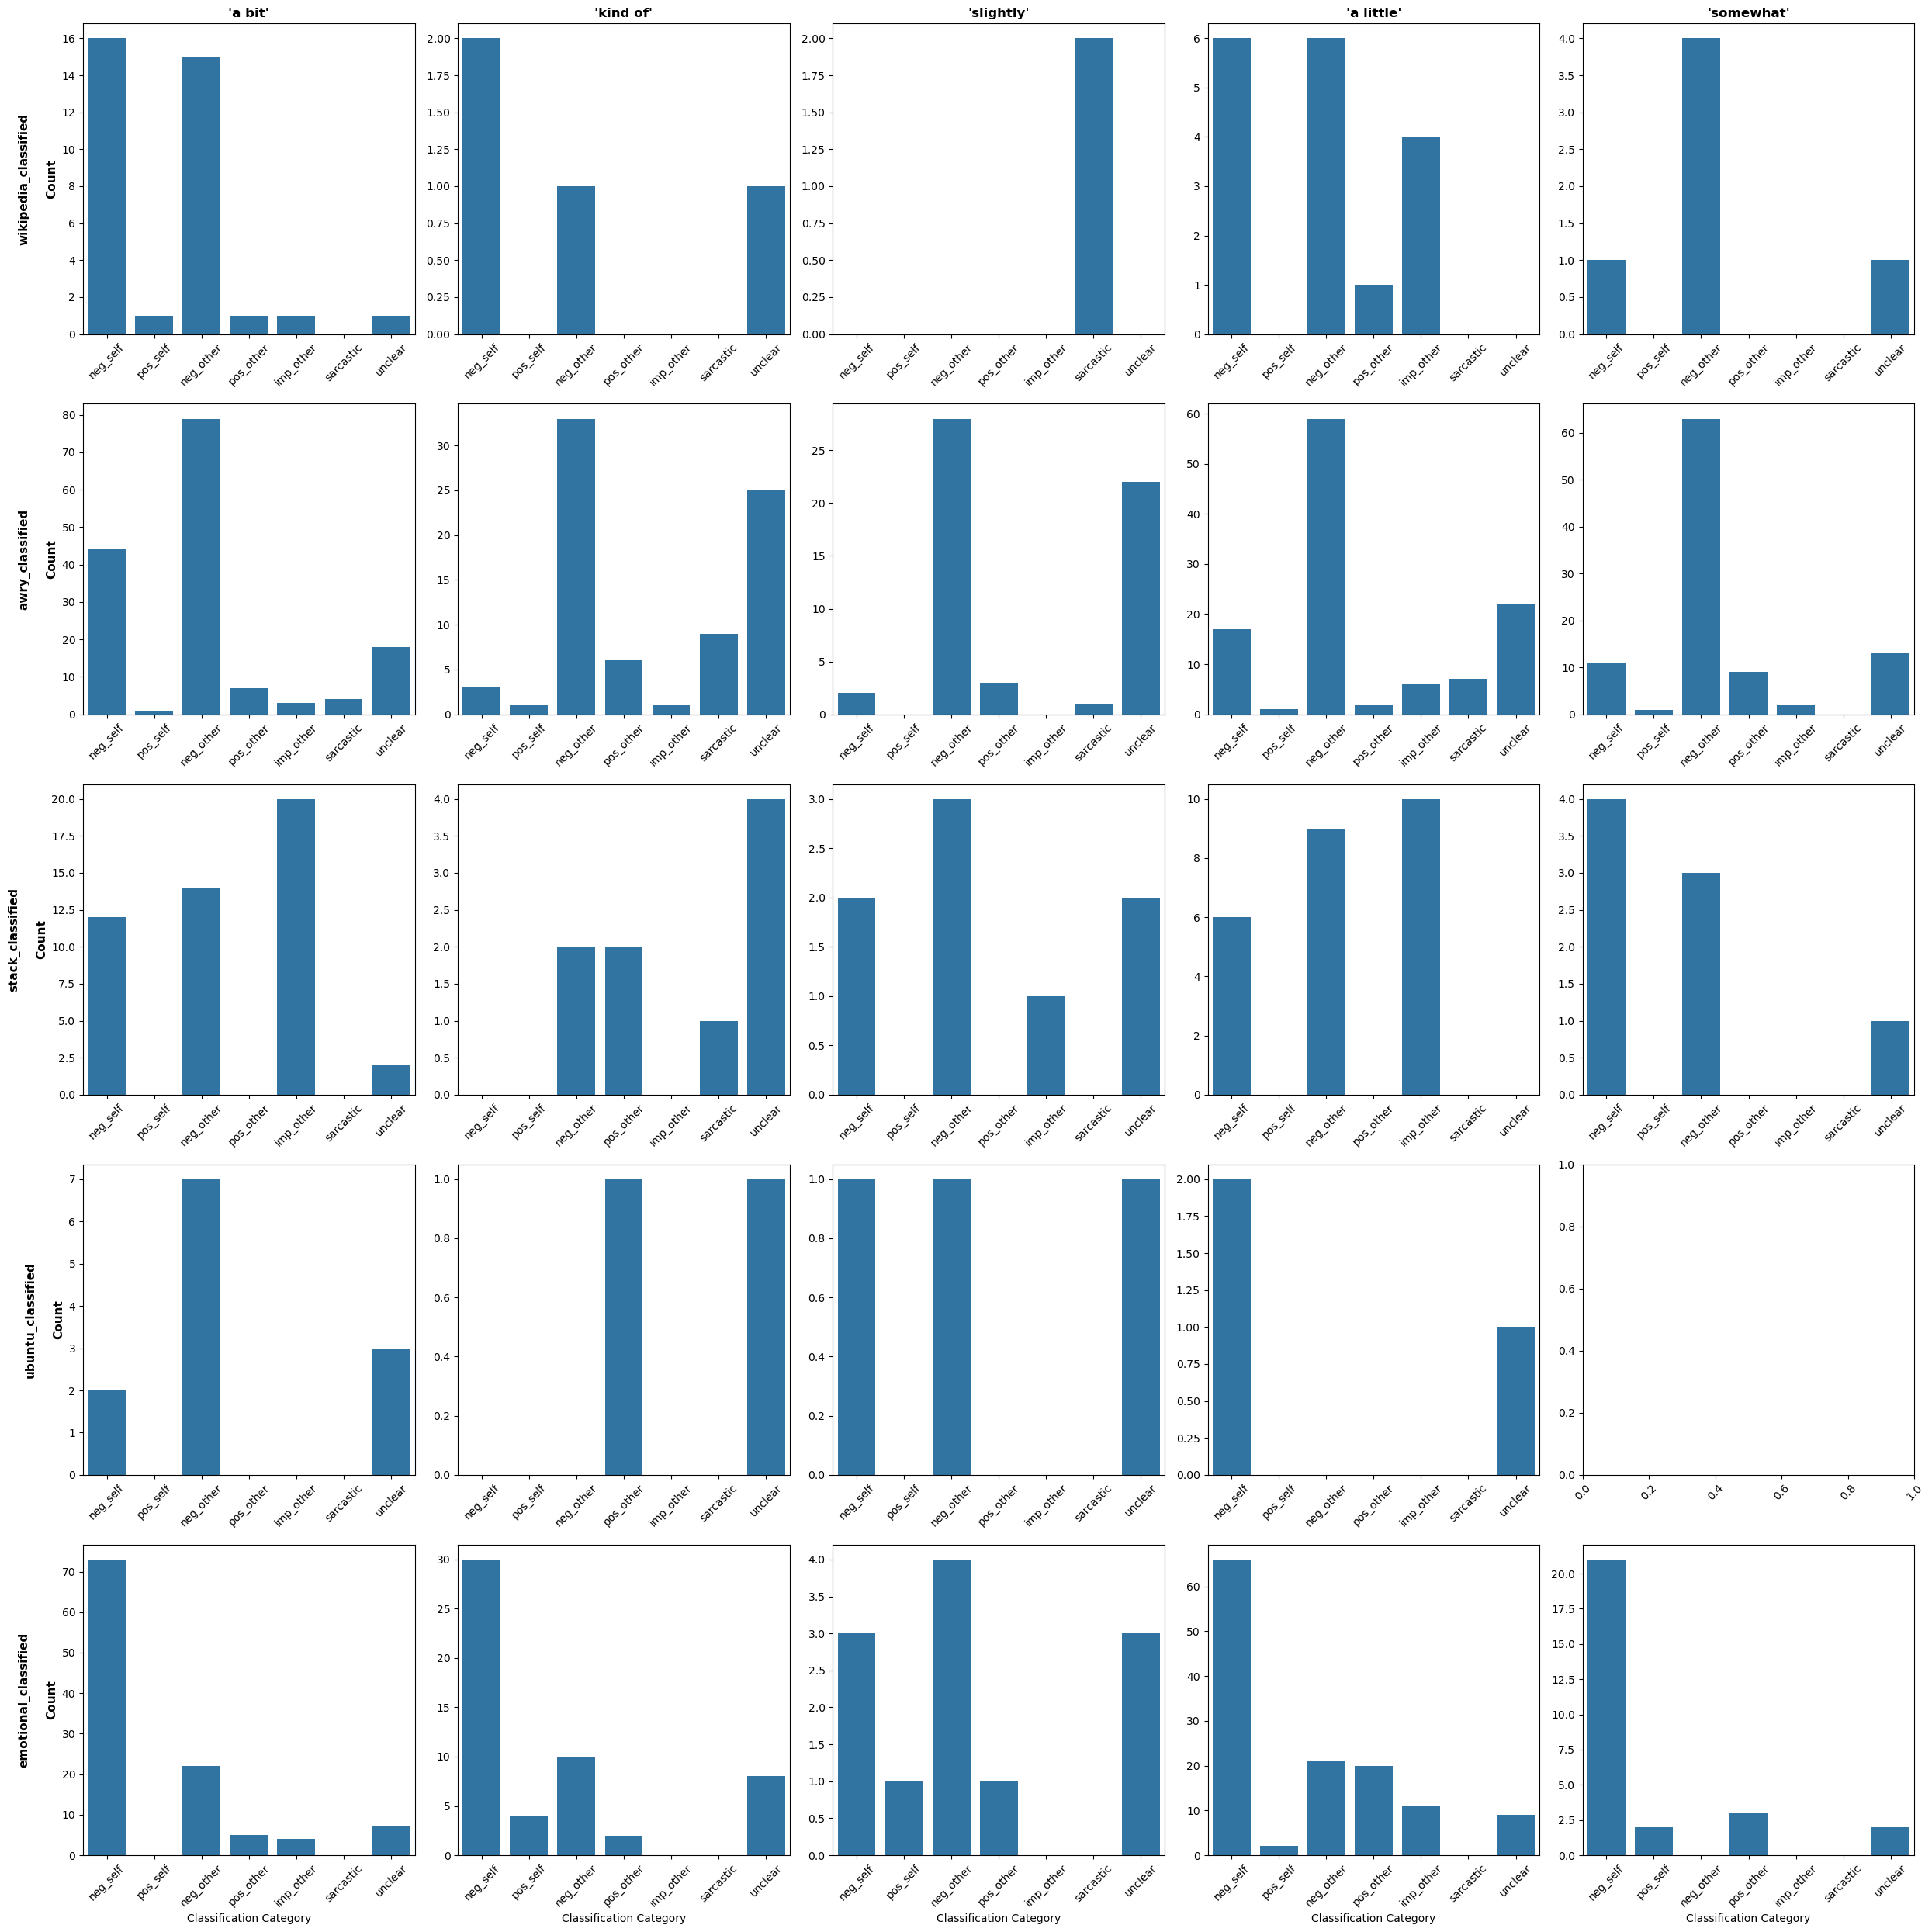

In [62]:
# Visualize classification for each dataset
import matplotlib.pyplot as plt
import seaborn as sns  

fig, axes = plt.subplots(5, 5, figsize=(25, 25))

for i in range(len(dfs)):
    modifiers = ["a bit", "kind of", "slightly", "a little", "somewhat"]
    
    for idx, modifier in enumerate(modifiers):
        # Filter data for current modifier
        modifier_data = dfs[i][dfs[i]['modifier'] == modifier]
        
        # Plot on the corresponding subplot
        sns.countplot(
            data=modifier_data, 
            x='classification', 
            order=["neg_self","pos_self","neg_other","pos_other","imp_other","sarcastic","unclear"],
            ax=axes[i][idx]
        )
        
        # Only add column titles on the first row
        if i == 0:
            axes[i][idx].set_title(f"'{modifier}'", fontsize=12, fontweight='bold')
        else:
            axes[i][idx].set_title('')
        
        # Only add x-label on the bottom row
        if i == len(dfs) - 1:
            axes[i][idx].set_xlabel('Classification Category')
        else:
            axes[i][idx].set_xlabel('')
        
        # Only add y-label on the first column
        if idx == 0:
            axes[i][idx].set_ylabel(f'{df_names[i]}\n\nCount', fontsize=11, fontweight='bold')
        else:
            axes[i][idx].set_ylabel('')
        
        axes[i][idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

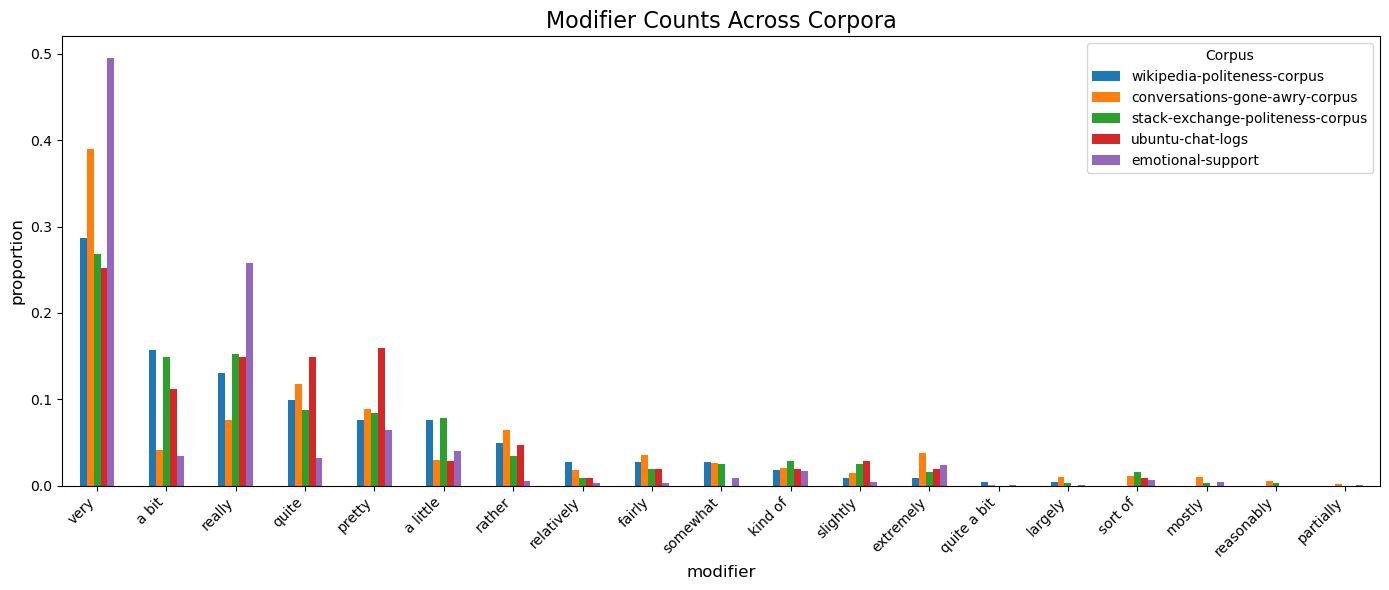

             wikipedia-politeness-corpus  conversations-gone-awry-corpus  \
very                            0.286996                        0.390231   
a bit                           0.156951                        0.040966   
really                          0.130045                        0.075893   
quite                           0.098655                        0.117910   
pretty                          0.076233                        0.088761   
a little                        0.076233                        0.029937   
rather                          0.049327                        0.064863   
relatively                      0.026906                        0.018120   
fairly                          0.026906                        0.035189   
somewhat                        0.026906                        0.025998   
kind of                         0.017937                        0.020483   
slightly                        0.008969                        0.014706   
extremely   

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the three modifier count dictionaries
df = pd.DataFrame({
    'wikipedia-politeness-corpus': modifier_wiki_requests_count,
    'conversations-gone-awry-corpus': modifier_awry_count,
    'stack-exchange-politeness-corpus': modifier_stack_count,
    # 'reddit-corpus-small': modifier_reddit_count, # this was too much data for new parser
    'ubuntu-chat-logs': modifier_ubuntu_count,
    'emotional-support': modifier_emotional_count
})

# Plot the data
fig, ax = plt.subplots(figsize=(14, 6))
df.plot(kind='bar', ax=ax)

ax.set_title('Modifier Counts Across Corpora', fontsize=16)
ax.set_xlabel('modifier', fontsize=12)
ax.set_ylabel('proportion', fontsize=12)
ax.legend(title='Corpus')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the dataframe
print(df)